# **Meeting 3 — Exploratory Data Analysis (EDA) & Data Visualization**
## Study Case: Bitcoin & Blockchain Economics

**Course:** Introduction to Data Science for Economics  
**Level:** Beginner / Economics students

### Main question
> **What economic patterns can we discover from historical Bitcoin market data using EDA and Data Visualization?**

### Learning Objectives
1. Understand computational descriptive statistics.
2. Explain Exploratory Data Analysis (EDA).
3. Explain why EDA is important.
4. Understand why data visualization is important.
5. Use Matplotlib and Seaborn for economic data.
6. Perform descriptive statistics.
7. Identify economic patterns from graphs.
8. Perform correlation analysis.
9. Understand feature engineering.
10. Apply feature selection, extraction, and scaling.


# 1. Economic Context: Bitcoin & Blockchain

Bitcoin is a cryptocurrency that uses **blockchain technology** as a distributed public ledger.

For economists, Bitcoin data can be used to study:
- Price
- Trading volume
- Market capitalization
- Returns
- Volatility
- Relationships between market variables

**Important:** This class is about understanding the data, not giving investment advice.


# 2. Dataset

We use the public Kaggle dataset:

**Bitcoin Historical Dataset (2010–2024)**

The dataset provides daily Bitcoin market information such as date, price, open/high/low, volume, and market capitalization.

**Kaggle:**  
https://www.kaggle.com/datasets/priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024

Kaggle datasets can change over time, so always inspect the actual file and columns after downloading.


# 3. What is EDA?

**Exploratory Data Analysis (EDA)** is the process of exploring and understanding data before building a statistical or Machine Learning model.

EDA helps us ask:
- What does the data look like?
- What variables do we have?
- What are typical values?
- Are there missing values?
- Are there outliers?
- Are there trends?
- Are variables related?

### Why is EDA important?
> **We should understand the data before modeling it.**

EDA helps us turn:
> "I have data."

into:
> "I understand what my data is telling me."


# 4. Why is Data Visualization Important?

Graphs make large amounts of information easier to:
- See
- Understand
- Compare
- Analyze
- Communicate

### Common tools
| Tool | Language | Typical use |
|---|---|---|
| Matplotlib | Python | Flexible plotting |
| Seaborn | Python | Statistical visualization |
| ggplot2 | R | Grammar-of-graphics visualization |

We use **Matplotlib and Seaborn** in this Python notebook.


# 5. Install and Import Libraries

We will use:
- `kagglehub` → download Kaggle data
- `pandas` → tables and data manipulation
- `numpy` → numerical calculations
- `matplotlib` → charts
- `seaborn` → statistical charts
- `scikit-learn` → feature scaling


In [ ]:
# Install KaggleHub so Google Colab can download a public Kaggle dataset.
!pip -q install kagglehub

# Import pandas for working with tables.
import pandas as pd

# Import numpy for numerical calculations.
import numpy as np

# Import matplotlib for creating charts.
import matplotlib.pyplot as plt

# Import seaborn for statistical visualization.
import seaborn as sns

# Import StandardScaler for feature scaling.
from sklearn.preprocessing import StandardScaler

# Set a simple Seaborn style for readable charts.
sns.set_theme(style="whitegrid")

# Print a message to confirm that the libraries are ready.
print("Libraries are ready!")

Libraries are ready!


# 6. Data Acquisition from Kaggle

**Data acquisition** means obtaining the data needed for analysis.

Other economic data sources include BPS, Bank Indonesia, OJK, APIs, government open-data portals, surveys, and financial databases.


In [ ]:
# Import kagglehub so we can download a public Kaggle dataset.
import kagglehub

# Download the selected Bitcoin dataset from Kaggle.
dataset_path = kagglehub.dataset_download("priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024")

# Print the folder where the dataset was downloaded.
print("Dataset location:", dataset_path)


Using Colab cache for faster access to the 'bitcoin-historical-prices-and-activity-2010-2024' dataset.
Dataset location: /kaggle/input/bitcoin-historical-prices-and-activity-2010-2024


In [ ]:
# Import glob so we can search for files inside the downloaded folder.
import glob

# Search for CSV files inside the dataset folder.
csv_files = glob.glob(dataset_path + "/**/*.csv", recursive=True)

# Print the CSV files that were found.
print("CSV files found:")

# Loop through every CSV file.
for file in csv_files:

    # Print the file path.
    print(file)


CSV files found:
/kaggle/input/bitcoin-historical-prices-and-activity-2010-2024/bitcoin_2010-07-17_2024-06-28.csv
/kaggle/input/bitcoin-historical-prices-and-activity-2010-2024/bitcoin_2010-07-17_2024-05-23.csv


# 7. Read the CSV File

CSV (**Comma-Separated Values**) is a common format for tabular economic data.


In [ ]:
import pandas as pd
# Check whether a CSV file was found.
if len(csv_files) == 0:

    # Stop the notebook if no CSV file was found.
    raise FileNotFoundError("No CSV file was found in the Kaggle dataset.")

# Select the first CSV file.
csv_file = csv_files[0]

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv(csv_file)

# Display the first five rows.
display(df.head())

,Start,End,Open,High,Low,Close,Volume,Market Cap
0,2024-06-27,2024-06-28,60882.90,62338.43,60666.19,61646.05,1.215887e+11,1.208392e+12
1,2024-06-26,2024-06-27,61733.99,62357.58,60761.24,60761.24,1.017576e+11,1.210544e+12
2,2024-06-25,2024-06-26,60317.99,62231.16,60272.58,61789.98,1.050312e+11,1.208415e+12
3,2024-06-24,2024-06-25,63168.03,63316.01,58946.24,60382.81,8.828355e+10,1.211101e+12
4,2024-06-23,2024-06-24,64276.04,64521.03,63290.43,63290.43,6.853945e+10,1.265327e+12


# 8. Inspect the Dataset

Before analysis, we should know:
- How many observations?
- What variables?
- What data types?
- What period?


In [ ]:
# Show the number of rows and columns.
print("Dataset shape:", df.shape)

# Standardize all column names to lowercase.
df.columns = [str(column).lower().strip() for column in df.columns]

# Display the standardized column names.
print("Columns:", df.columns.tolist())

# Display the data types.
print("\nData types:")

# Show the data types of each column.
print(df.dtypes)

# Display the first five rows.
print("\nFirst five rows:")

# Show the first five observations.
display(df.head())


Dataset shape: (5095, 8)
Columns: ['start', 'end', 'open', 'high', 'low', 'close', 'volume', 'market cap']

Data types:
start          object
end            object
open          float64
high          float64
low           float64
close         float64
volume        float64
market cap    float64
dtype: object

First five rows:


,start,end,open,high,low,close,volume,market cap
0,2024-06-27,2024-06-28,60882.90,62338.43,60666.19,61646.05,1.215887e+11,1.208392e+12
1,2024-06-26,2024-06-27,61733.99,62357.58,60761.24,60761.24,1.017576e+11,1.210544e+12
2,2024-06-25,2024-06-26,60317.99,62231.16,60272.58,61789.98,1.050312e+11,1.208415e+12
3,2024-06-24,2024-06-25,63168.03,63316.01,58946.24,60382.81,8.828355e+10,1.211101e+12
4,2024-06-23,2024-06-24,64276.04,64521.03,63290.43,63290.43,6.853945e+10,1.265327e+12


# 9. Prepare the Date Variable

Time is important because Bitcoin market data is a **time series**.

We need the date to be recognized as a date rather than plain text.


In [ ]:
# Create a list of common names for date columns.
possible_date_columns = ["date", "start", "datetime", "timestamp"]

# Find the first matching date column.
date_column = next((column for column in possible_date_columns if column in df.columns), None)

# Check whether a date column was found.
if date_column is None:

    # Stop the notebook if no date column can be identified.
    raise ValueError("A date column could not be identified.")

# Convert the date column into pandas datetime format.
df[date_column] = pd.to_datetime(df[date_column], errors="coerce")

# Remove rows where the date could not be converted.
df = df.dropna(subset=[date_column])

# Sort the observations by date.
df = df.sort_values(date_column)

# Display the date range.
print("Start date:", df[date_column].min())

# Display the final date.
print("End date:", df[date_column].max())


Start date: 2010-07-17 00:00:00
End date: 2024-06-27 00:00:00


# 10. Check Missing Values and Duplicates

EDA should identify data-quality issues before interpretation.


In [ ]:
# Count missing values in each column.
missing_values = df.isnull().sum()

# Display the missing-value counts.
display(missing_values.to_frame("missing_count"))

# Count duplicate rows.
duplicate_count = df.duplicated().sum()

# Display the number of duplicates.
print("Duplicate rows:", duplicate_count)


,missing_count
start,0
end,0
open,0
high,0
low,0
close,0
volume,0
market cap,0


Duplicate rows: 0


# 11. Find Important Economic Variables

Different datasets may use different names for the same concept.

We will search for common Bitcoin variables such as:
- Price / Close
- Volume
- Market Cap
- Open
- High
- Low


In [ ]:
# Define a helper function for finding a column.
def find_column(possible_names):

    # Check every possible name.
    for name in possible_names:

        # Check whether the name exists.
        if name in df.columns:

            # Return the matching column.
            return name

    # Return None if no name was found.
    return None

# Find the Bitcoin price column.
price_col = find_column(["price", "close", "closing_price"])

# Find the volume column.
volume_col = find_column(["volume", "vol"])

# Find the market capitalization column.
market_cap_col = find_column(["market cap", "market_cap", "marketcap"])

# Find the open-price column.
open_col = find_column(["open"])

# Find the high-price column.
high_col = find_column(["high"])

# Find the low-price column.
low_col = find_column(["low"])

# Print the detected variables.
print("Price:", price_col)
print("Volume:", volume_col)
print("Market Cap:", market_cap_col)
print("Open:", open_col)
print("High:", high_col)
print("Low:", low_col)


Price: close
Volume: volume
Market Cap: market cap
Open: open
High: high
Low: low


# 12. Computational Descriptive Statistics

Descriptive statistics summarize numerical data.

### Central tendency
- Mean
- Median

### Dispersion
- Standard deviation
- Minimum
- Maximum
- Quartiles

### Economic question
> What is the typical Bitcoin price, and how much does it vary?


In [ ]:
# Select all numerical columns.
numeric_data = df.select_dtypes(include="number")

# Calculate descriptive statistics.
descriptive_stats = numeric_data.describe().T

# Display the descriptive statistics.
display(descriptive_stats)


,count,mean,std,min,25%,50%,75%,max
open,5095.0,1.183171e+04,1.742270e+04,0.05,2.303010e+02,2.608560e+03,1.711309e+04,7.296103e+04
high,5095.0,1.210281e+04,1.781394e+04,0.05,2.346045e+02,2.757940e+03,1.744475e+04,7.362843e+04
low,5095.0,1.154707e+04,1.700674e+04,0.05,2.269530e+02,2.538550e+03,1.683380e+04,7.133336e+04
close,5095.0,1.184495e+04,1.743875e+04,0.05,2.303855e+02,2.610600e+03,1.709806e+04,7.308795e+04
volume,5095.0,2.135086e+10,3.373560e+10,0.00,8.455034e+06,1.224709e+09,3.429250e+10,2.121515e+11
market cap,5095.0,2.229693e+11,3.352850e+11,0.00,3.295801e+09,4.296678e+10,3.253326e+11,1.428493e+12


# 13. Visualization — Bitcoin Price Distribution

A **histogram** helps us understand the distribution of a numerical variable.

We can look for:
- Concentration
- Spread
- Long tails
- Extreme values


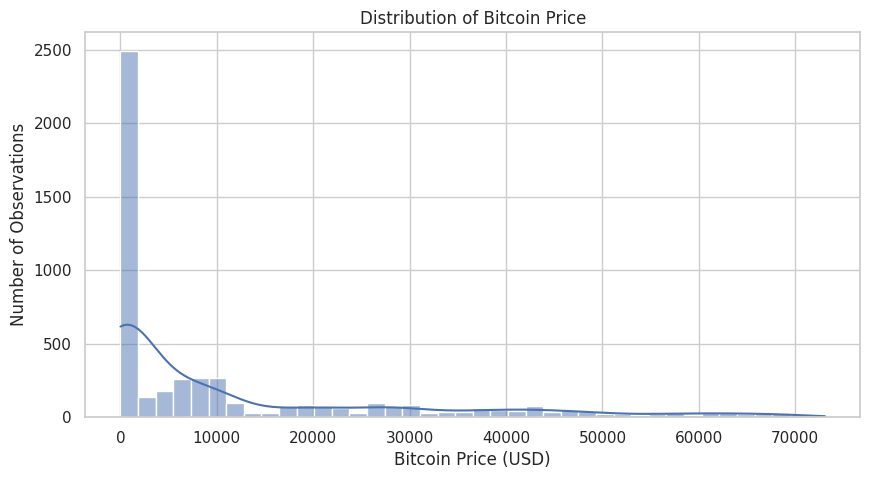

In [ ]:
# Check whether a price column was found.
if price_col is not None:

    # Create a new figure.
    plt.figure(figsize=(10, 5))

    # Draw a histogram of Bitcoin prices.
    sns.histplot(df[price_col].dropna(), bins=40, kde=True)

    # Add a title.
    plt.title("Distribution of Bitcoin Price")

    # Label the x-axis.
    plt.xlabel("Bitcoin Price (USD)")

    # Label the y-axis.
    plt.ylabel("Number of Observations")

    # Display the chart.
    plt.show()


# 14. Visualization — Bitcoin Price Over Time

A **line chart** is useful for time-series data.

Economic questions:
- Is there a long-term trend?
- When did prices rise sharply?
- When did prices fall sharply?
- Are there periods of high volatility?


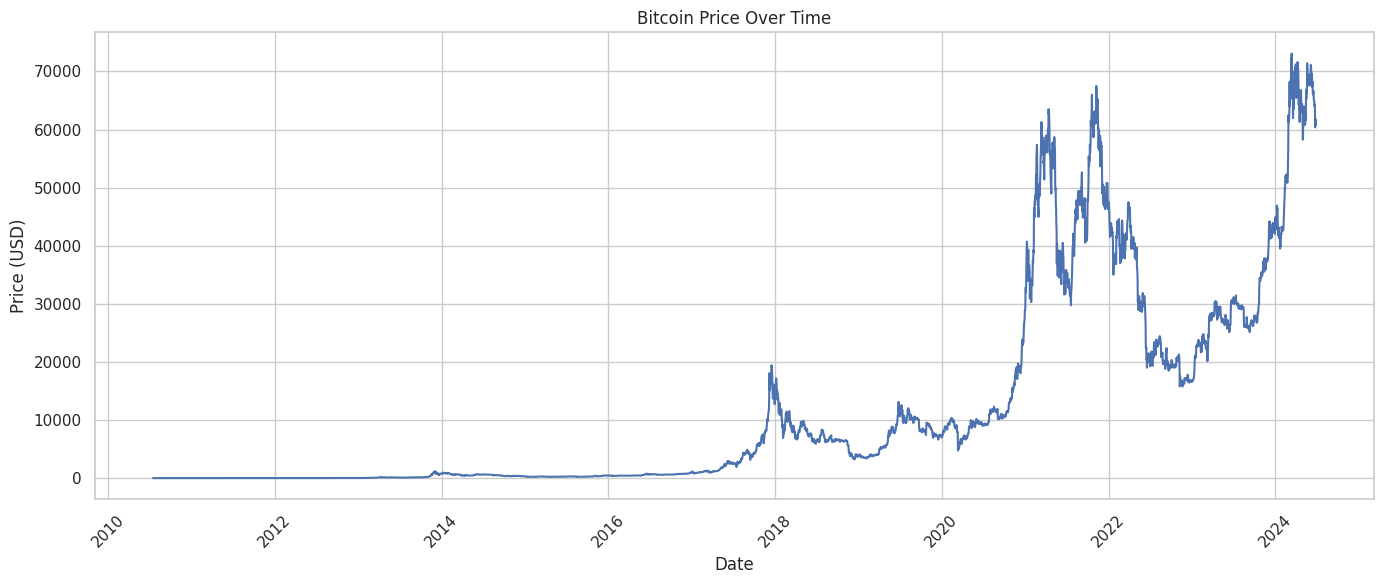

In [ ]:
# Define a helper function for finding a column.
def find_column(possible_names):
    # Check every possible name.
    for name in possible_names:
        # Check whether the name exists.
        if name in df.columns:
            # Return the matching column.
            return name
    # Return None if no name was found.
    return None

# Find the Bitcoin price column.
price_col = find_column(["price", "close", "closing_price"])

# Create a list of common names for date columns.
possible_date_columns = ["date", "start", "datetime", "timestamp"]

# Find the first matching date column.
date_column = next((column for column in possible_date_columns if column in df.columns), None)

# Check whether a date column was found.
if date_column is None:
    raise ValueError("A date column could not be identified.")

# Convert the date column into pandas datetime format.
df[date_column] = pd.to_datetime(df[date_column], errors="coerce")

# Remove rows where the date could not be converted.
df = df.dropna(subset=[date_column])

# Sort the observations by date.
df = df.sort_values(date_column)

# Check whether a price column was found.
if price_col is not None:

    # Create a new figure.
    plt.figure(figsize=(14, 6))

    # Plot Bitcoin price against time.
    plt.plot(df[date_column], df[price_col])

    # Add a title.
    plt.title("Bitcoin Price Over Time")

    # Label the x-axis.
    plt.xlabel("Date")

    # Label the y-axis.
    plt.ylabel("Price (USD)")

    # Rotate the date labels.
    plt.xticks(rotation=45)

    # Adjust the layout.
    plt.tight_layout()

    # Display the chart.
    plt.show()

# 15. Visualization — Trading Volume

Trading volume can help us understand market activity.

A useful economic question is:

> **Do periods of large price movements happen together with high trading volume?**

A graph helps us investigate this question.


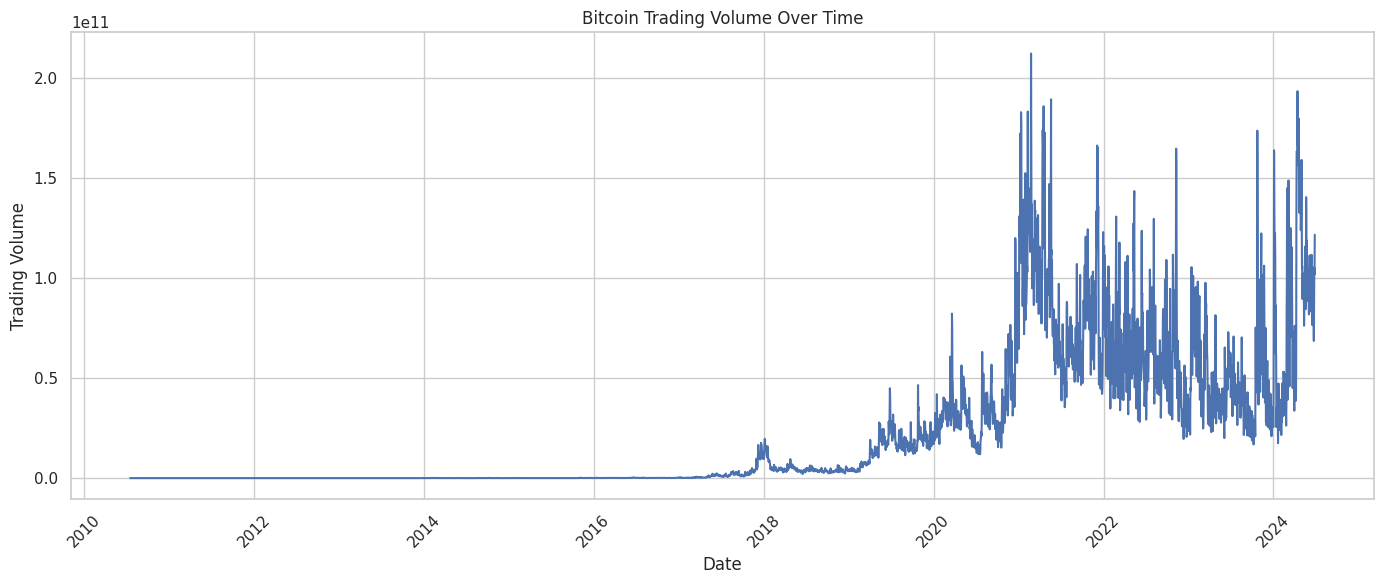

In [ ]:
# Check whether a volume column exists.
if volume_col is not None:

    # Create a new figure.
    plt.figure(figsize=(14, 6))

    # Plot trading volume over time.
    plt.plot(df[date_column], df[volume_col])

    # Add a title.
    plt.title("Bitcoin Trading Volume Over Time")

    # Label the x-axis.
    plt.xlabel("Date")

    # Label the y-axis.
    plt.ylabel("Trading Volume")

    # Rotate the date labels.
    plt.xticks(rotation=45)

    # Adjust the layout.
    plt.tight_layout()

    # Display the chart.
    plt.show()


# 16. Visualization — Box Plot

A **box plot** helps us see:
- Median
- Quartiles
- Spread
- Potential outliers


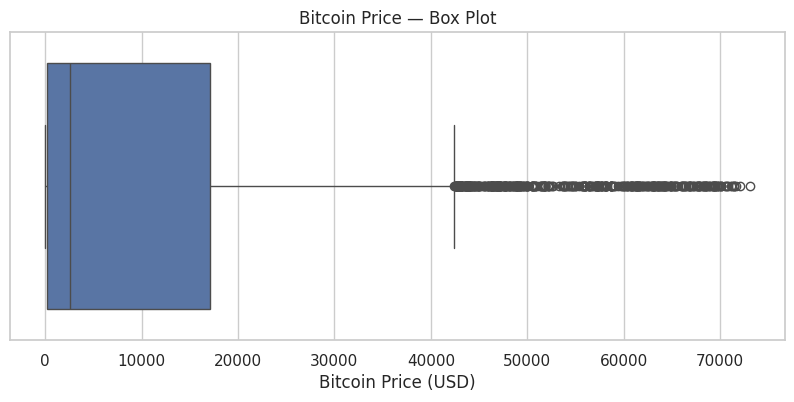

In [ ]:
# Check whether a price column exists.
if price_col is not None:

    # Create a new figure.
    plt.figure(figsize=(10, 4))

    # Draw a box plot of Bitcoin prices.
    sns.boxplot(x=df[price_col])

    # Add a title.
    plt.title("Bitcoin Price — Box Plot")

    # Label the x-axis.
    plt.xlabel("Bitcoin Price (USD)")

    # Display the chart.
    plt.show()


# 17. Feature Engineering — Daily Return

**Feature engineering** means creating or transforming variables to make them more useful for analysis or Machine Learning.

For financial data, a percentage return is often more informative than the raw price.

\[
Return_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]


In [ ]:
# Check whether a price column exists.
if price_col is not None:

    # Calculate the percentage change from one observation to the next.
    df["daily_return"] = df[price_col].pct_change()

    # Display price and daily return.
    display(df[[price_col, "daily_return"]].head(10))


,close,daily_return
5094,0.0500,NaN
5093,0.0858,0.716000
5092,0.0808,-0.058275
5091,0.0747,-0.075495
5090,0.0792,0.060241
5089,0.0505,-0.362374
5088,0.0626,0.239604
5087,0.0545,-0.129393
5086,0.0505,-0.073394
5085,0.0560,0.108911


# 18. Visualize Daily Returns

A return distribution can help us understand:
- Typical daily movements
- Volatility
- Extreme positive movements
- Extreme negative movements


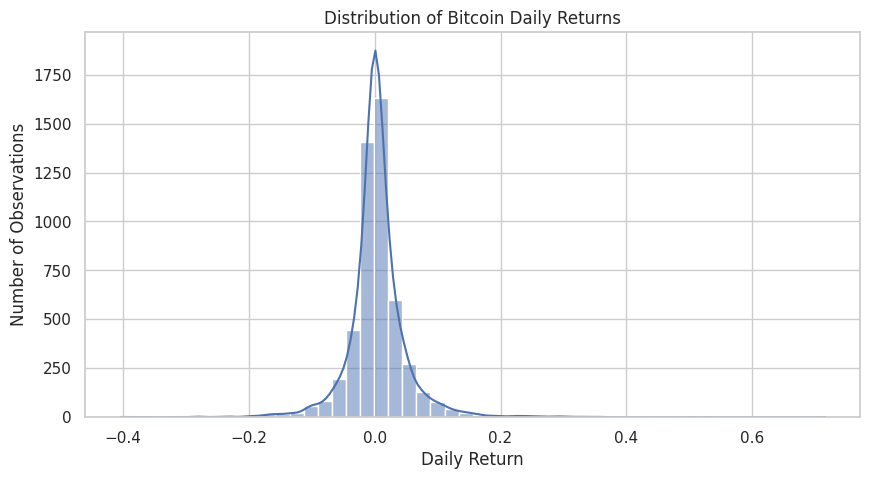

In [ ]:
# Check whether daily returns were created.
if "daily_return" in df.columns:

    # Create a new figure.
    plt.figure(figsize=(10, 5))

    # Draw the distribution of daily returns.
    sns.histplot(df["daily_return"].dropna(), bins=50, kde=True)

    # Add a title.
    plt.title("Distribution of Bitcoin Daily Returns")

    # Label the x-axis.
    plt.xlabel("Daily Return")

    # Label the y-axis.
    plt.ylabel("Number of Observations")

    # Display the chart.
    plt.show()


# 19. Correlation Analysis

Correlation measures the direction and strength of a **linear relationship** between two numerical variables.

\[
-1 \leq r \leq 1
\]

- Close to **+1** → strong positive linear relationship
- Close to **0** → weak/no linear relationship
- Close to **-1** → strong negative linear relationship

> **Correlation does not imply causation.**


In [ ]:
# Select numerical variables.
correlation_data = df.select_dtypes(include="number")

# Calculate the Pearson correlation matrix.
correlation_matrix = correlation_data.corr()

# Display the correlation matrix.
display(correlation_matrix)


,open,high,low,close,volume,market cap,daily_return
open,1.000000,0.999624,0.999424,0.999166,0.873823,0.999274,-0.040014
high,0.999624,1.000000,0.999292,0.999637,0.876023,0.999207,-0.031266
low,0.999424,0.999292,1.000000,0.999567,0.869087,0.999524,-0.030329
close,0.999166,0.999637,0.999567,1.000000,0.872758,0.999266,-0.023096
volume,0.873823,0.876023,0.869087,0.872758,1.000000,0.870413,-0.033126
market cap,0.999274,0.999207,0.999524,0.999266,0.870413,1.000000,-0.031388
daily_return,-0.040014,-0.031266,-0.030329,-0.023096,-0.033126,-0.031388,1.000000


# 20. Correlation Heatmap

A heatmap makes the correlation matrix easier to read visually.


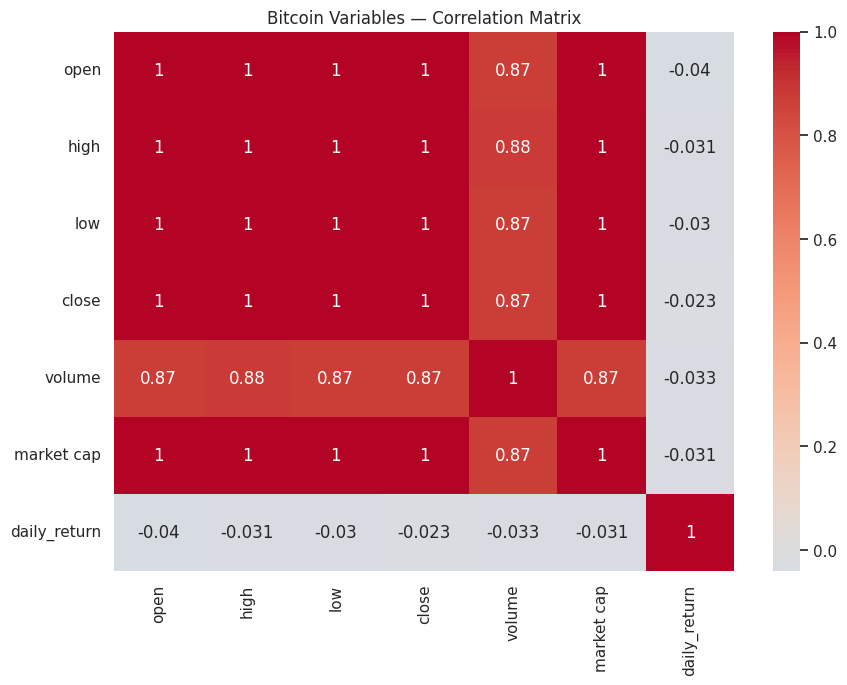

In [ ]:
# Create a new figure.
plt.figure(figsize=(10, 7))

# Draw the correlation matrix as a heatmap.
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)

# Add a title.
plt.title("Bitcoin Variables — Correlation Matrix")

# Display the chart.
plt.show()


# 21. Scatter Plot — Price vs Volume

A scatter plot allows us to visually inspect the relationship between two variables.

Question:

> **Do higher-volume observations tend to have higher Bitcoin prices?**

Remember: association is not causation.


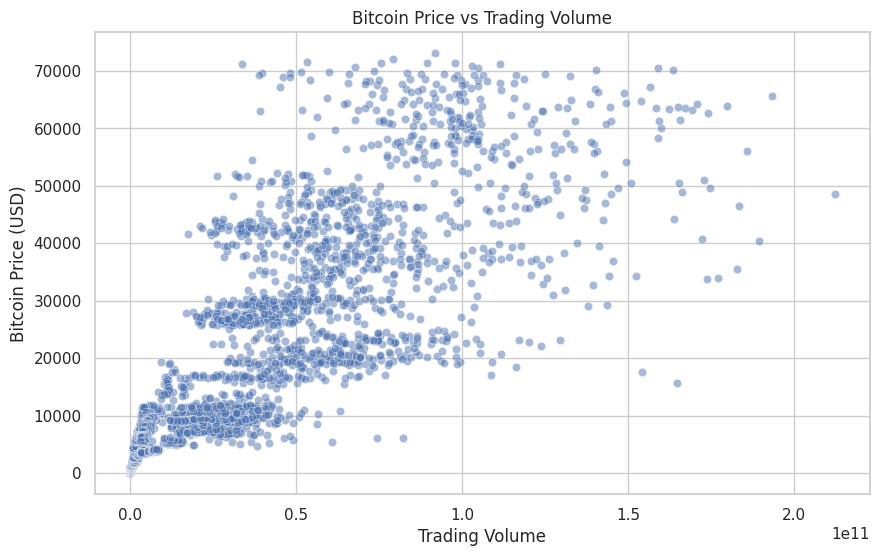

In [ ]:
# Check whether price and volume are available.
if price_col is not None and volume_col is not None:

    # Create a new figure.
    plt.figure(figsize=(10, 6))

    # Draw a scatter plot of volume against price.
    sns.scatterplot(data=df, x=volume_col, y=price_col, alpha=0.5)

    # Add a title.
    plt.title("Bitcoin Price vs Trading Volume")

    # Label the x-axis.
    plt.xlabel("Trading Volume")

    # Label the y-axis.
    plt.ylabel("Bitcoin Price (USD)")

    # Display the chart.
    plt.show()

# 22. Feature Engineering Technique 1 — Feature Selection

**Feature selection** means choosing variables that are relevant to the research question.

For example, if we study Bitcoin market behavior, we may select:
- Price
- Volume
- Market Cap
- Daily Return

We do not necessarily need every variable in the original dataset.


In [ ]:
# Create an empty list for selected features.
selected_features = []

# Add price if it exists.
if price_col is not None:
    selected_features.append(price_col)

# Add volume if it exists.
if volume_col is not None:
    selected_features.append(volume_col)

# Add market cap if it exists.
if market_cap_col is not None:
    selected_features.append(market_cap_col)

# Add daily return if it exists.
if "daily_return" in df.columns:
    selected_features.append("daily_return")

# Print the selected features.
print("Selected features:", selected_features)

# Create a smaller dataset using only selected features.
selected_data = df[selected_features].copy()

# Display the selected dataset.
display(selected_data.head())


Selected features: ['close', 'volume', 'market cap', 'daily_return']


,close,volume,market cap,daily_return
5094,0.0500,0.0,0.0,NaN
5093,0.0858,0.0,0.0,0.716000
5092,0.0808,0.0,0.0,-0.058275
5091,0.0747,0.0,0.0,-0.075495
5090,0.0792,0.0,0.0,0.060241


# 23. Feature Engineering Technique 2 — Feature Extraction

**Feature extraction** creates a new feature from existing information.

Example:

\[
Daily\ Range = High - Low
\]

This gives us a simple measure of the price movement within a day.


In [ ]:
# Check whether high and low price columns exist.
if high_col is not None and low_col is not None:

    # Create a new feature representing the daily price range.
    df["daily_range"] = df[high_col] - df[low_col]

    # Display the original variables and the new feature.
    display(df[[high_col, low_col, "daily_range"]].head())


,high,low,daily_range
5094,0.0500,0.0500,0.0
5093,0.0858,0.0858,0.0
5092,0.0808,0.0808,0.0
5091,0.0747,0.0747,0.0
5090,0.0792,0.0792,0.0


# 24. Another Feature: Rolling Volatility

We can also create a simple 7-observation rolling volatility measure.

This is an example of feature extraction from historical returns.


In [ ]:
# Check whether daily returns are available.
if "daily_return" in df.columns:

    # Calculate the rolling standard deviation over seven observations.
    df["rolling_volatility_7d"] = df["daily_return"].rolling(window=7).std()

    # Display the new volatility feature.
    display(df[["daily_return", "rolling_volatility_7d"]].tail(10))


,daily_return,rolling_volatility_7d
9,-0.020938,0.013706
8,-0.002287,0.011215
7,-0.001062,0.009181
6,-0.012080,0.009353
5,0.002738,0.009416
4,-0.015284,0.008756
3,-0.045941,0.016618
2,0.023304,0.021139
1,-0.016649,0.021276
0,0.014562,0.023029


# 25. Feature Engineering Technique 3 — Feature Scaling

Different variables can have very different numerical scales.

For example:
- Price → thousands of USD
- Volume → potentially millions
- Return → small decimal values

Standardization transforms a variable using:

$$
z = \frac{x-\mu}{\sigma}
$$

Where:

- $z$ = standardized value (z-score)
- $x$ = original value
- $\mu$ = mean of the variable
- $\sigma$ = standard deviation of the variable
- $x-\mu$ = distance between the observation and the mean

Interpretation

- $z = 0$ → the value is exactly at the mean
- $z > 0$ → the value is above the mean
- $z < 0$ → the value is below the mean
- $z = 1$ → the value is 1 standard deviation above the mean
- $z = -2$ → the value is 2 standard deviations below the mean

</br>
After standardization:

- Mean ≈ 0
- Standard deviation ≈ 1
After standardization, the feature has approximately:
- Mean = 0
- Standard deviation = 1

Scaling is especially useful for algorithms that are sensitive to feature magnitude.

In [ ]:
# Create an empty list for variables that can be scaled.
scaling_features = []

# Add price if it exists.
if price_col is not None:
    scaling_features.append(price_col)

# Add volume if it exists.
if volume_col is not None:
    scaling_features.append(volume_col)

# Add market cap if it exists.
if market_cap_col is not None:
    scaling_features.append(market_cap_col)

# Keep only rows without missing values in these variables.
scaling_data = df[scaling_features].dropna()

# Create a StandardScaler object.
scaler = StandardScaler()

# Standardize the selected features.
scaled_values = scaler.fit_transform(scaling_data)

# Convert the scaled values back into a pandas DataFrame.
scaled_data = pd.DataFrame(scaled_values, columns=scaling_features, index=scaling_data.index)

# Display the first five scaled observations.
display(scaled_data.head())

,close,volume,market cap
5094,-0.679295,-0.63295,-0.665079
5093,-0.679293,-0.63295,-0.665079
5092,-0.679293,-0.63295,-0.665079
5091,-0.679294,-0.63295,-0.665079
5090,-0.679294,-0.63295,-0.665079


# 26. EDA Workflow — From Data to Economic Insight

We have completed:

**1. Data Acquisition**  
↓  
**2. Data Inspection**  
↓  
**3. Data Quality Check**  
↓  
**4. Descriptive Statistics**  
↓  
**5. Visualization**  
↓  
**6. Correlation Analysis**  
↓  
**7. Feature Engineering**  
↓  
**8. Economic Interpretation**

### The key idea

EDA is not simply about creating graphs.

It is about:

> **asking questions → finding patterns → checking relationships → interpreting the patterns economically**


# Student Exercise

## Question

> **What economic patterns can you discover from Bitcoin market data?**

### Task 1 — Descriptive Statistics
Report:
- Mean price
- Median price
- Minimum price
- Maximum price
- Standard deviation

### Task 2 — Visualization
Create:
1. A line chart of Bitcoin price.
2. A histogram of daily returns.
3. A scatter plot of price vs volume.

### Task 3 — Correlation
Identify:
- The strongest positive correlation.
- The strongest negative correlation.

### Task 4 — Feature Engineering
Create at least **two new features**, for example:
- Daily return
- Daily range
- Rolling volatility

### Task 5 — Economic Interpretation
Write 3–5 sentences answering:

> **What economic pattern did you discover, and what might explain it?**

Possible concepts:
- Market demand
- Market activity
- Liquidity
- Volatility
- Speculation
- Investor behavior


# Final Takeaways

### Descriptive Statistics
Summarize data numerically.

### EDA
Helps us explore and understand data before modeling.

### Visualization
Helps us see trends, distributions, outliers, and relationships.

### Correlation
Measures the direction and strength of a linear relationship.

### Feature Selection
Chooses relevant variables.

### Feature Extraction
Creates new variables from existing information.

### Feature Scaling
Puts numerical features on comparable scales.

---

## From Data → Information → Economic Insight

**Raw Data**  
↓  
**EDA**  
↓  
**Statistics + Visualization**  
↓  
**Patterns**  
↓  
**Economic Interpretation**  
↓  
**Better Data Science Decisions**


# References & Data Sources

### Main Dataset
**Kaggle — Bitcoin Historical Dataset (2010–2024)**  
https://www.kaggle.com/datasets/priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024

### Recommended References
1. Consoli, S., Reforgiato Recupero, D., & Saisana, M. (Eds.). (2021). *Data Science for Economics and Finance: Methodologies and Applications*. Springer.
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer.
4. Matplotlib: https://matplotlib.org/stable/
5. Seaborn: https://seaborn.pydata.org/
6. scikit-learn: https://scikit-learn.org/stable/
7. ggplot2: https://ggplot2.tidyverse.org/

### Important
Historical EDA describes historical observations. Correlation does not establish causation, and historical cryptocurrency patterns do not guarantee future market behavior.
